## Import The Library Needed

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
import string
from statistics import mode
import random
import matplotlib.pyplot as plt

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.stem import SnowballStemmer, WordNetLemmatizer

# Dataset I: Semantic Analysis Dataset

## Dataset I (SA):  EDA & Preprocess I

In [ ]:
# Load the dataset
dataset = pd.read_csv('../Dataset/Emotion_classify_Data(Labeled).csv')

In [ ]:
dataset

,Comment,Emotion
0,i seriously hate one subject to death but now i feel reluctant to drop it,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feelings and i think that i am afraid to accept the possibility that he might not make it,fear
3,ive been really angry with r and i feel like an idiot for trusting him in the first place,joy
4,i feel suspicious if there is no one outside like the rapture has happened or something,fear
...,...,...
5932,i begun to feel distressed for you,fear
5933,i left feeling annoyed and angry thinking that i was the center of some stupid joke,anger
5934,i were to ever get married i d have everything ready to offer to him because i ve got it together and when i do go out to clubs even the perfect good looking guys feel intimated after talking to me about my clever self,joy
5935,i feel reluctant in applying there because i want to be able to find a company where i know at least one person,fear


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5937 non-null   object
 1   Emotion  5937 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB


In [ ]:
dataset.describe()

,Comment,Emotion
count,5937,5937
unique,5934,3
top,i feel like a tortured artist when i talk to her,anger
freq,2,2000


In [ ]:
mode_values = dataset['Comment'].mode()  # Get the mode values (can be multiple)
mode_indices = []

for mode_value in mode_values:
    indices = dataset.index[dataset['Comment'] == mode_value]  # Get indices of rows where Comment equals mode_value
    mode_indices.extend(indices)
print("Mode values:")
print(mode_values)
print("Indices of mode values:", mode_indices)

# Fetching the second column for each mode value
second_column_values = []
for index in mode_indices:
    second_column_values.append(dataset.iloc[index]['Emotion'])

print("Emotion values corresponding to the mode values:", second_column_values)

Mode values:
0     i feel like a tortured artist when i talk to her
1    i feel pretty tortured because i work a job an...
2    i resorted to yesterday the post peak day of i...
Name: Comment, dtype: object
Indices of mode values: [2262, 5870, 2877, 4869, 986, 1930]
Emotion values corresponding to the mode values: ['anger', 'fear', 'anger', 'fear', 'anger', 'fear']


In [ ]:
dataset = dataset.drop_duplicates(subset='Comment', keep='first')
dataset.describe()

,Comment,Emotion
count,5934,5934
unique,5934,3
top,i seriously hate one subject to death but now ...,anger
freq,1,2000


In [ ]:
dataset.isnull().sum()

Comment    0
Emotion    0
dtype: int64

In [ ]:
# Assuming 'dataset' is your DataFrame
emotion_distribution = dataset['Emotion'].value_counts()

# Print the distribution
print(emotion_distribution)


anger    2000
joy      2000
fear     1934
Name: Emotion, dtype: int64


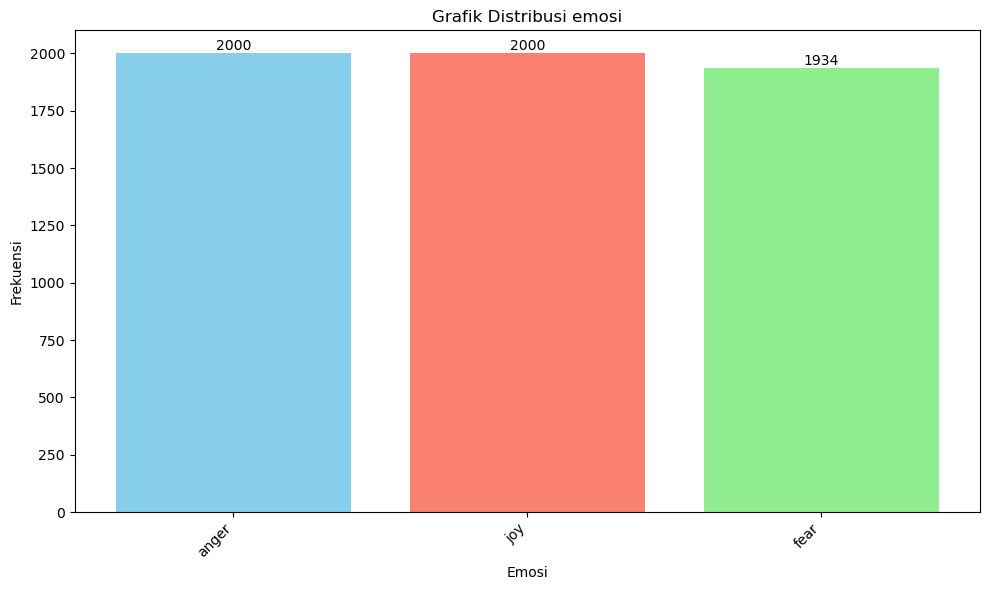

In [ ]:
# Count the stopwords in my Dataset
labels = list(emotion_distribution.keys())
freq = list(emotion_distribution.values)

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, freq, color= ['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Emosi')
plt.ylabel('Frekuensi')
plt.title('Grafik Distribusi emosi')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, '%d' % int(height),
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
dataset.to_csv('../Dataset/(Preprocessed)Emotion_classify_Data(Labeled).csv', index=False)

## Dataset I (SA): EDA & Preprocess II

In [ ]:
dataset = pd.read_csv('../Dataset/(Preprocessed)Emotion_classify_Data(Labeled).csv')
dataset

,Comment,Emotion
0,i seriously hate one subject to death but now i feel reluctant to drop it,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feelings and i think that i am afraid to accept the possibility that he might not make it,fear
3,ive been really angry with r and i feel like an idiot for trusting him in the first place,joy
4,i feel suspicious if there is no one outside like the rapture has happened or something,fear
...,...,...
5929,i begun to feel distressed for you,fear
5930,i left feeling annoyed and angry thinking that i was the center of some stupid joke,anger
5931,i were to ever get married i d have everything ready to offer to him because i ve got it together and when i do go out to clubs even the perfect good looking guys feel intimated after talking to me about my clever self,joy
5932,i feel reluctant in applying there because i want to be able to find a company where i know at least one person,fear


In [ ]:
# save the Preprocess II method in new py into thePreprocessingII.py
from thePreprocessingII import preProcess

In [ ]:
commentList = dataset['Comment'].to_list()
emotionList = dataset['Emotion'].to_list()

In [ ]:
stopsList = stopwords.words('english')
punctList = string.punctuation
stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

def getLabel(tag):
    if tag == 'jj': return 'a'
    elif tag in ['vb', 'nn', 'rb']: return tag[0]
    else: return None


def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w not in stopsList]
    tokens = [w for w in tokens if w not in punctList]
    tokens = [w for w in tokens if w.isalpha()]
    # Stem and lemmatize the tokens
    pos_tags = pos_tag(tokens)
    # tokens = [stemmer.stem(lemmatizer.lemmatize(token)) for token in tokens]
    processed_tokens = []
    for word, tag in pos_tags:
        wordnet_tag = getLabel(tag)
        if wordnet_tag:
            lemma = lemmatizer.lemmatize(word, wordnet_tag)
        else:
            lemma = lemmatizer.lemmatize(word)
        stemmed = stemmer.stem(lemma)
        processed_tokens.append(stemmed)
    return ' '.join(processed_tokens)

preprocessedList = [preprocess_text(comment) for comment in commentList]

preprocessedList

['serious hate one subject death feel reluct drop',
 'im full life feel appal',
 'sit write start dig feel think afraid accept possibl might make',
 'ive realli angri r feel like idiot trust first place',
 'feel suspici one outsid like raptur happen someth',
 'feel jealous becasu want kind love true connect two soul want',
 'friend mine keep tell morbid thing happen dog',
 'final fell asleep feel angri useless still full anxieti',
 'feel bit annoy antsi good way',
 'feel like regain anoth vital part life live',
 'feel bit like franz liebkind produc mani peopl know fuhrer terrif dancer',
 'feel start didnt want move much realli glad experi glimps sort vibrant energi gain year',
 'bitten dog',
 'alway find feel thank year gather trick allow feel grate face moment last thing want say thank',
 'tri talk anyon feel irrit like',
 'feel like hate sinc',
 'dont know wrote follow littl note feel today u r offend follow post obvious live long enough compromis act believ',
 'feel offend choos tel

In [ ]:
preProcessIISentList = preprocessedList

import json
# Save list to a file
with open('../Dataset/(PreprocessedII)sentList.json', 'w') as f:
    json.dump(preProcessIISentList, f)

In [ ]:
# Load list from file
with open('../Dataset/(PreprocessedII)sentList.json', 'r') as f:
    loaded_list = json.load(f)

loaded_list

['serious hate one subject death feel reluct drop',
 'im full life feel appal',
 'sit write start dig feel think afraid accept possibl might make',
 'ive realli angri r feel like idiot trust first place',
 'feel suspici one outsid like raptur happen someth',
 'feel jealous becasu want kind love true connect two soul want',
 'friend mine keep tell morbid thing happen dog',
 'final fell asleep feel angri useless still full anxieti',
 'feel bit annoy antsi good way',
 'feel like regain anoth vital part life live',
 'feel bit like franz liebkind produc mani peopl know fuhrer terrif dancer',
 'feel start didnt want move much realli glad experi glimps sort vibrant energi gain year',
 'bitten dog',
 'alway find feel thank year gather trick allow feel grate face moment last thing want say thank',
 'tri talk anyon feel irrit like',
 'feel like hate sinc',
 'dont know wrote follow littl note feel today u r offend follow post obvious live long enough compromis act believ',
 'feel offend choos tel

# Dataset II: Recommendation System Dataset

## LOADUP Trained Model BERT

In [ ]:
dataset = pd.read_csv('../Dataset/(Preprocessed)Emotion_classify_Data(Labeled).csv')

In [ ]:
# Shuffle the dataset
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Load pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=dataset['Emotion'].nunique())

# Fine-tune BERT on your dataset
learning_rate = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.CrossEntropyLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

c:\Users\Michael Dimas\anaconda3\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
emotion_labels = dataset['Emotion']

# Instantiate the label encoder
label_encoder = LabelEncoder()

# Fit the label encoder to the encoded emotion labels
label_encoder.fit(emotion_labels)


LabelEncoder()

In [ ]:
# Load the checkpoint
checkpoint = torch.load('last_trained_model_checkpoint.pth' , map_location=torch.device('cpu'))

# Load model and optimizer states
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [ ]:
def predict_emotion(text, label_encoder):
    # Tokenize the text using the same tokenizer used during training
    inputs = tokenizer.encode_plus(text, add_special_tokens=True, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)  # Move input to the same device as the model
    attention_mask = inputs['attention_mask'].to(device)  # Move attention mask to the same device as the model

    # Make prediction
    with torch.no_grad():
        model.eval()  # Set model to evaluation mode
        outputs = model(input_ids, attention_mask=attention_mask)
    logits = outputs.logits

    # Get predicted label
    predicted_label = torch.argmax(logits, dim=1).item()

    # Decode the predicted label using label_encoder
    predicted_emotion = label_encoder.inverse_transform([predicted_label])[0]

    return predicted_emotion, logits

# Example usage
text = "Super happy today"
predicted_emotion, x = predict_emotion(text, label_encoder)
print(f'Predicted Emotion: {predicted_emotion}')
print(f'Predicted Label: {x}')

Predicted Emotion: joy
Predicted Label: tensor([[-2.6676, -2.7545,  6.4300]])


## Quotes Dataset

In [ ]:
quotes = pd.read_json('../Dataset/quotes.json')
quotes.head(2)

,Quote,Author,Tags,Popularity,Category
0,"Don't cry because it's over, smile because it happened.",Dr. Seuss,"[attributed-no-source, cry, crying, experience, happiness, joy, life, misattributed-dr-seuss, optimism, sadness, smile, smiling ]",0.155666,life
1,"Don't cry because it's over, smile because it happened.",Dr. Seuss,"[attributed-no-source, cry, crying, experience, happiness, joy, life, misattributed-dr-seuss, optimism, sadness, smile, smiling ]",0.155666,happiness


In [ ]:
#Check if there is NaN Values in Rows
quotes.isnull().sum()

Quote         0
Author        0
Tags          0
Popularity    0
Category      0
dtype: int64

In [ ]:
df_selected = quotes[['Quote', 'Author']]
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48391 entries, 0 to 48390
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Quote   48391 non-null  object
 1   Author  48391 non-null  object
dtypes: object(2)
memory usage: 756.2+ KB


In [ ]:
df_selected.describe()

,Quote,Author
count,48391,48391
unique,36937,13839
top,Your ordinary acts of love and hope point to the extraordinary promise that every human life is of inestimable value.,Beryl Dov
freq,16,3321


In [ ]:
# Drop rows where the "Quote" column is duplicated
df_filtered = df_selected.drop_duplicates(subset='Quote', keep='first')
df_filtered.describe()

,Quote,Author
count,36937,36937
unique,36937,13810
top,"Don't cry because it's over, smile because it happened.",Beryl Dov
freq,1,878


## Give emotion to the Quotes

In [ ]:
def label_quotes_with_emotions(quotes_df):
    emotions = []
    for idx, quote in enumerate(quotes_df['Quote']):
        emotion, x = predict_emotion(quote, label_encoder)
        emotions.append(emotion)
        print(idx, quote)
    quotes_df['emotion'] = emotions

In [ ]:
# Label the quotes in the dataset with emotions
label_quotes_with_emotions(df_filtered)

0 Don't cry because it's over, smile because it happened.
1 I'm selfish, impatient and a little insecure. I make mistakes, I am out of control and at times hard to handle. But if you can't handle me at my worst, then you sure as hell don't deserve me at my best.
2 Be yourself; everyone else is already taken.
3 Two things are infinite: the universe and human stupidity; and I'm not sure about the universe.
4 Be who you are and say what you feel, because those who mind don't matter, and those who matter don't mind.
5 You've gotta dance like there's nobody watching,Love like you'll never be hurt,Sing like there's nobody listening,And live like it's heaven on earth.
6 You know you're in love when you can't fall asleep because reality is finally better than your dreams.
7 A room without books is like a body without a soul.
8 So many books, so little time.
9 You only live once, but if you do it right, once is enough.
10 Be the change that you wish to see in the world.
11 In three words I can 

C:\Users\Michael Dimas\AppData\Local\Temp\ipykernel_24856\2325366262.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quotes_df['emotion'] = emotions


In [ ]:
df_filtered.describe()

,Quote,Author,emotion
count,36937,36937,36937
unique,36937,13810,3
top,"Don't cry because it's over, smile because it happened.",Beryl Dov,joy
freq,1,878,24777


In [ ]:
df_filtered.head(5)

,Quote,Author,emotion
0,"Don't cry because it's over, smile because it happened.",Dr. Seuss,joy
2,"I'm selfish, impatient and a little insecure. I make mistakes, I am out of control and at times hard to handle. But if you can't handle me at my worst, then you sure as hell don't deserve me at my best.",Marilyn Monroe,anger
5,Be yourself; everyone else is already taken.,Oscar Wilde,anger
6,Two things are infinite: the universe and human stupidity; and I'm not sure about the universe.,Albert Einstein,joy
9,"Be who you are and say what you feel, because those who mind don't matter, and those who matter don't mind.",Bernard M. Baruch,joy


In [ ]:
# Save the preprocessed dataset to csv
df_filtered.to_csv('./Dataset/(Preprocessed)quotes.csv', index=False)